# Week 9 Phase 1.20: G3 chooses, M3 predicts

A step-by-step explanation of acquisition sample efficiency on a frozen finite simulation pool. ST means substrate temperature; the target is any observed Keyhole frame.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd()
while not (ROOT/'src').is_dir(): ROOT=ROOT.parent
OUT=ROOT/'outputs/week9_phase1_20_m3_g3_margin_acquisition'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'G3_budget': 16,
 'G3_max_probability_error': 1.1368683772161603e-13,
 'M3_budget': 24,
 'M3_max_probability_error': 5.685243942288309e-13,
 'checks': {'gate10_G3_prediction_parity': True,
  'gate11_M3_prediction_and_path_parity': True,
  'gate1_population': True,
  'gate2_splits': True,
  'gate3_A0': True,
  'gate4_P1': True,
  'gate5_initial': True,
  'split_sizes_and_group_protection': True,
  'stored_validation_week9_phase1_12_gpc_kernel_adequacy': True,
  'stored_validation_week9_phase1_13_fixed_physics_ard_discrepancy': True,
  'stored_validation_week9_phase1_14_m3_margin_acquisition': True},
 'parity_run': 'w85__r01_f01',
 'status': 'PASS'}

## 1. The three paths

P0 is the frozen historical Week 8.5 GPC margin path. P1 is the stored Phase 1.14 M3 margin path. P2 is the new sequential G3 margin path. A path records the order in which labels become available. The evaluator is M3 in every arm.

In [2]:
paths=pd.read_csv(OUT/'query_paths.csv.gz')
display(paths.groupby('model').agg(runs=('run_id','nunique'),rows=('query_order','count')))
display(paths[(paths.run_id=='w85__r01_f01') & paths.query_order.between(14,21)].pivot(index='query_order',columns='model',values='population_row_index'))

,runs,rows
model,,
P0,100,8000
P1,100,8000
P2,100,8000


model,P0,P1,P2
query_order,,,
14,111,111,111
15,189,189,189
16,391,391,391
17,87,115,106
18,89,80,149
19,126,93,81
20,385,106,76
21,103,103,110


## 2. Why P2 is not A0

The historical GPC shares one kernel length scale across the four standardized inputs. G3 uses automatic relevance determination (ARD): a separate learned length scale for each input. The kernel remains Matérn-3/2. This changes the selector model; P2 must therefore be fitted live rather than replaying A0.

In [3]:
audit=json.loads((OUT/'selector_specification_audit.json').read_text())
display(pd.DataFrame({k:audit[k] for k in ['Week8.5','G3']}).T)

,fit,kernel,lengthscales,seed
Week8.5,p6.fit_gpc; w85.run_trajectory,"1**2 * Matern(length_scale=1, nu=1.5)",1,w85.fit_seed_key / seed_u32
G3,p12.fit_gpc_model / predict_positive,"1**2 * Matern(length_scale=[1, 1, 1, 1], nu=1.5)",4,"p12.seed_u32(G3, run_id, budget)"


## 3. Why G3 can select while M3 evaluates

M3 models the latent function as a fitted physics mean based on log(h) plus a four-dimensional GP discrepancy. It predicts Keyhole probability on held-out rows. Separately, standalone G3 ranks candidates by distance of its probability from 0.5. The discrepancy inside M3 is not an independent Keyhole classifier.

## 4. One sequential step

At B=16, fit G3 on the shared 16 revealed labels. Score every remaining training-pool candidate. Choose the minimum |p−0.5|, resolving exact ties by smallest population row index. Reveal the chosen label. At B=17 refit from the updated prefix. Continue until 80 labels are available. At each budget, fit M3 on that prefix and evaluate it on the untouched test set.

In [4]:
margins=pd.read_csv(OUT/'selector_margin_diagnostics.csv.gz')
display(margins[(margins.run_id=='w85__r01_f01') & (margins.budget<=20)])

,run_id,repeat,model,budget,selected_margin
0,w85__r01_f01,1,P2,16,0.000011
1,w85__r01_f01,1,P2,17,0.002853
2,w85__r01_f01,1,P2,18,0.004682
3,w85__r01_f01,1,P2,19,0.007901
4,w85__r01_f01,1,P2,20,0.009397
6400,w85__r01_f01,1,P1,16,0.019733
6401,w85__r01_f01,1,P1,17,0.003749
6402,w85__r01_f01,1,P1,18,0.001892
6403,w85__r01_f01,1,P1,19,0.008702
6404,w85__r01_f01,1,P1,20,0.044363


## 5. Preventing information leakage

The selector receives training-pool features and revealed labels only. The test set and q20/q30 membership belong to evaluation. The 100 grouped splits are fixed; test information cannot determine the next query. Stored candidate probabilities permit independent checks of all selected minima.

In [5]:
validation=json.loads((OUT/'validation_report.json').read_text())
display(pd.DataFrame(list(validation['checks'].items()),columns=['Gate','Passed']))
display(pd.read_csv(OUT/'fit_diagnostics_summary.csv'))

,Gate,Passed
0,all_run_B16_M3_parity,True
1,complete_metric_grid,True
2,frozen_q20_q30_memberships,True
3,frozen_split_manifest_exact,True
4,gate10_G3_prediction_parity,True
5,gate11_M3_prediction_and_path_parity,True
6,gate1_population,True
7,gate2_100_runs,True
8,gate2_splits,True
9,gate3_A0,True


,model,fit_count,fallback_count,optimizer_converged_fraction,optimized_primary_fraction,any_length_bound_fraction
0,G3,6400,0,NaN,1.0,0.851719
1,M3,6500,0,0.919231,NaN,0.645231


## 6. What balanced accuracy and AULC mean

Keyhole recall is the fraction of actual Keyhole rows correctly predicted. Conduction recall is defined similarly. Balanced accuracy is their average, so a large Conduction class does not dominate the score. AULC is the trapezoidal area under the learning curve divided by its budget span. For B16–B40 the span is 24. Earlier phase headline AULCs used ordinary accuracy; these are different endpoints.

In [6]:
metrics=pd.read_csv(OUT/'checkpoint_metrics.csv')
display(metrics[(metrics.subset=='B1_q20') & metrics.budget.isin([16,24,40])])

,model,subset,budget,balanced_accuracy,accuracy,keyhole_recall,false_negative,false_positive
0,P0,B1_q20,16,0.771914,0.785882,0.722119,1.80,1.84
1,P0,B1_q20,24,0.809953,0.825882,0.748353,1.64,1.32
3,P0,B1_q20,40,0.836261,0.849412,0.772440,1.51,1.05
18,P1,B1_q20,16,0.771914,0.785882,0.722119,1.80,1.84
19,P1,B1_q20,24,0.798836,0.817059,0.728770,1.76,1.35
21,P1,B1_q20,40,0.827068,0.846471,0.748738,1.62,0.99
36,P2,B1_q20,16,0.771914,0.785882,0.722119,1.80,1.84
37,P2,B1_q20,24,0.805704,0.824706,0.734758,1.71,1.27
39,P2,B1_q20,40,0.818554,0.834706,0.745274,1.68,1.13


## 7. Primary early-budget result

The predeclared primary contrast is P2 minus P1 on q20 balanced-accuracy AULC B16–B40. Each repeat averages five folds; inference resamples 20 repeat blocks. The 100 folds are not treated as independent.

,model,subset,end_budget,mean_AULC,ci_lower,ci_upper
0,P0,B1_q20,40,0.810516,0.802044,0.818795
4,P1,B1_q20,40,0.807353,0.800365,0.814203
8,P2,B1_q20,40,0.804793,0.794009,0.814363


,contrast,subset,end_budget,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,bootstrap_draws,seed,inference_role
0,P2-P1,B1_q20,40,-0.00256,-0.01057,0.005446,9,0,10000,2286804453,primary


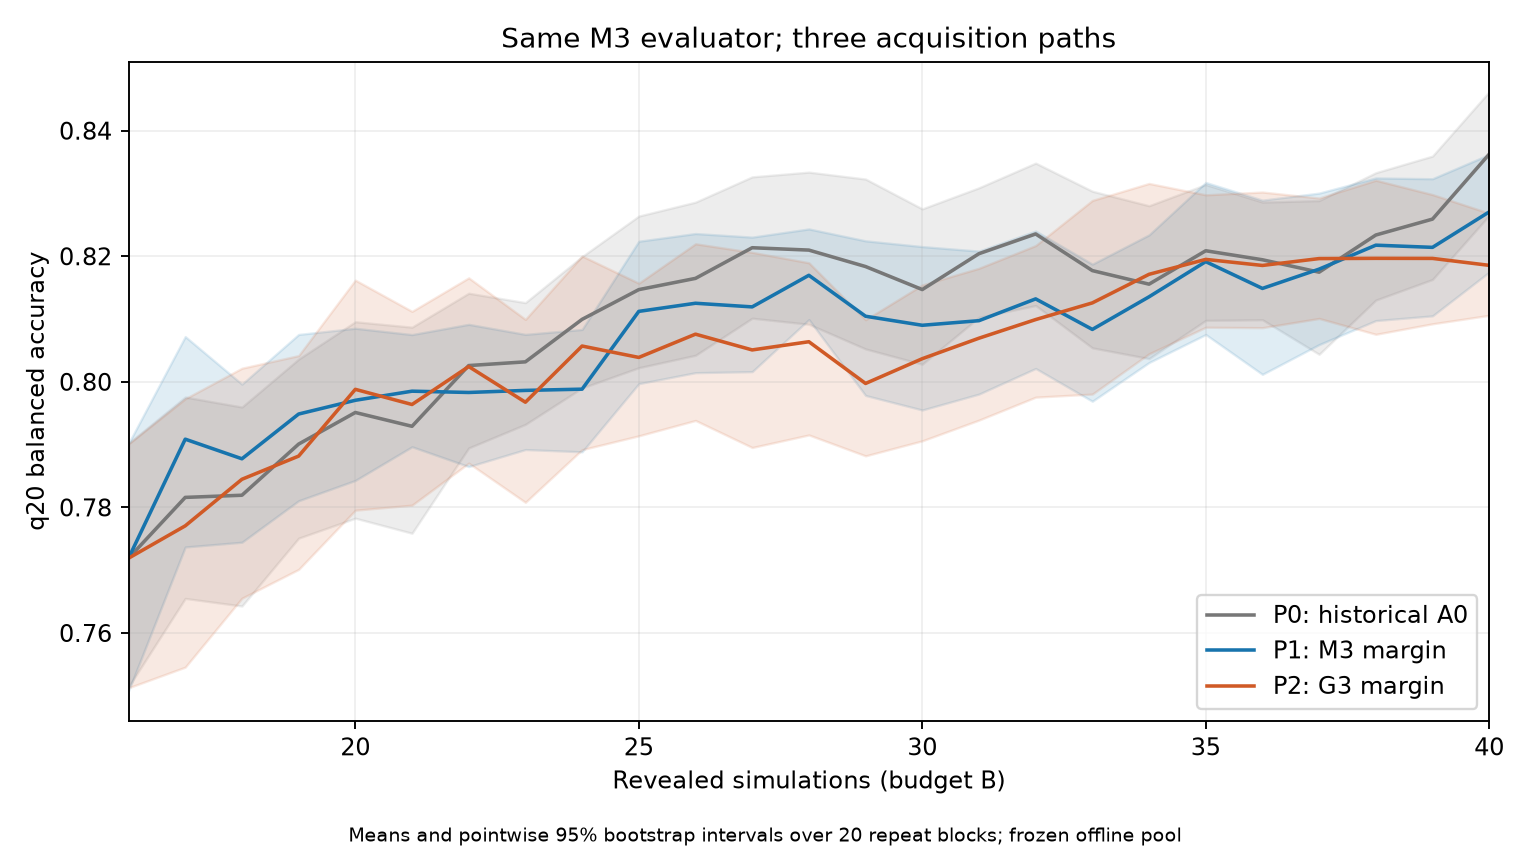

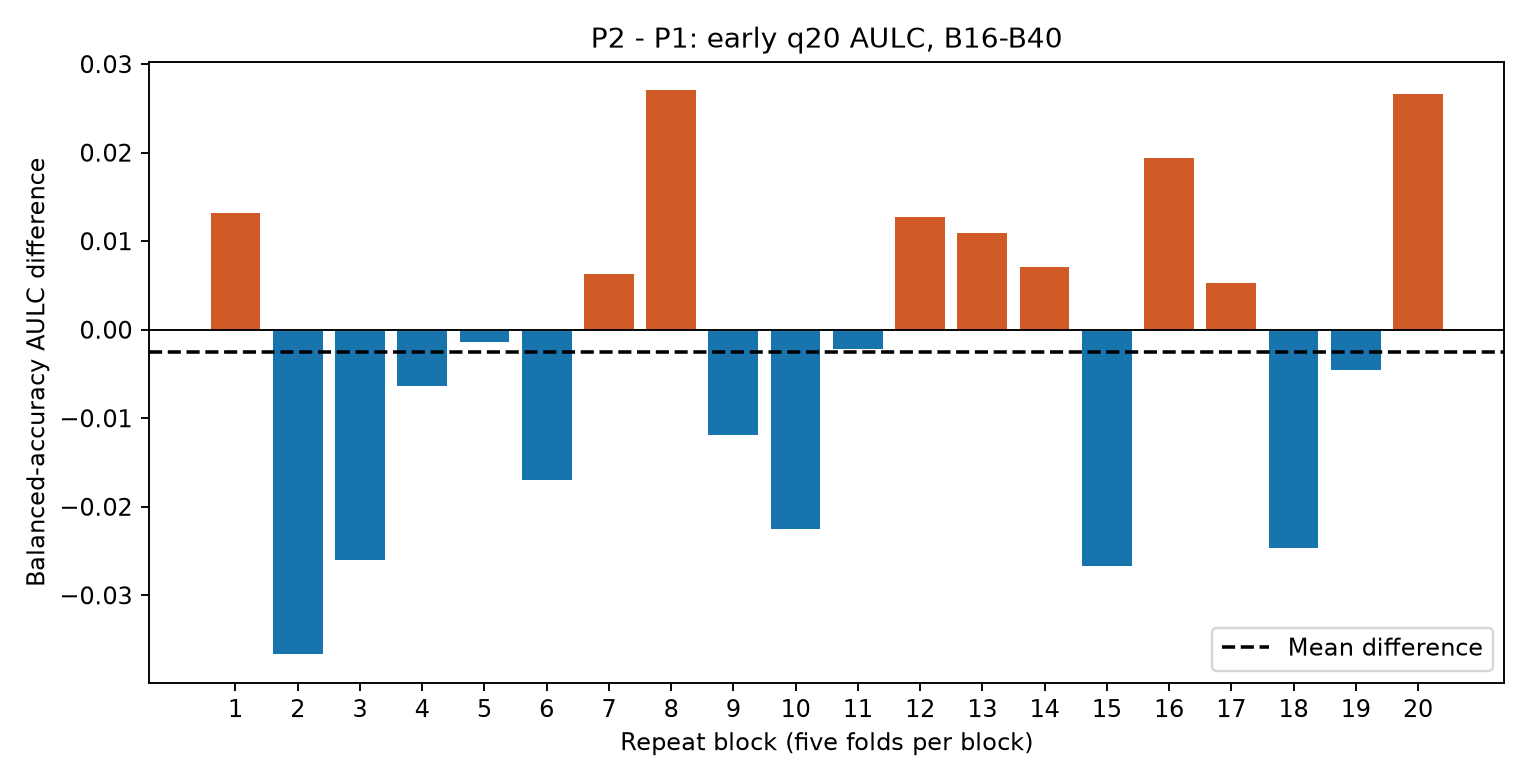

In [7]:
contrasts=pd.read_csv(OUT/'paired_contrasts.csv')
aulc=pd.read_csv(OUT/'AULC_summary.csv')
display(aulc[(aulc.subset=='B1_q20') & (aulc.end_budget==40)])
display(contrasts[contrasts.inference_role=='primary'])
display(Image(filename=str(OUT/'figures/02_early_q20_zoom.png')))
display(Image(filename=str(OUT/'figures/03_early_P2_minus_P1.png')))

## 8. Full-budget and secondary results

The B16–B80 view checks whether later behavior changes the picture. q30 and P2 versus P0 are secondary descriptive checks. They do not replace the predeclared primary endpoint.

,contrast,subset,end_budget,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,bootstrap_draws,seed,inference_role
1,P2-P0,B1_q20,40,-0.005724,-0.012324,0.000581,7,0,10000,2599148892,secondary descriptive
2,P2-P1,B1_q20,80,-0.007014,-0.011681,-0.002494,7,0,10000,1320338375,secondary descriptive
3,P2-P0,B1_q20,80,-0.005839,-0.010089,-0.001525,6,0,10000,3326407179,secondary descriptive
4,P2-P1,B1_q30,40,-0.005331,-0.011833,0.001250,6,0,10000,3560789404,secondary descriptive
5,P2-P0,B1_q30,40,-0.006100,-0.011265,-0.000961,6,0,10000,2090614420,secondary descriptive
6,P2-P1,B1_q30,80,-0.008808,-0.012533,-0.005184,3,0,10000,1409692847,secondary descriptive
7,P2-P0,B1_q30,80,-0.005972,-0.009376,-0.002696,4,0,10000,2701655718,secondary descriptive


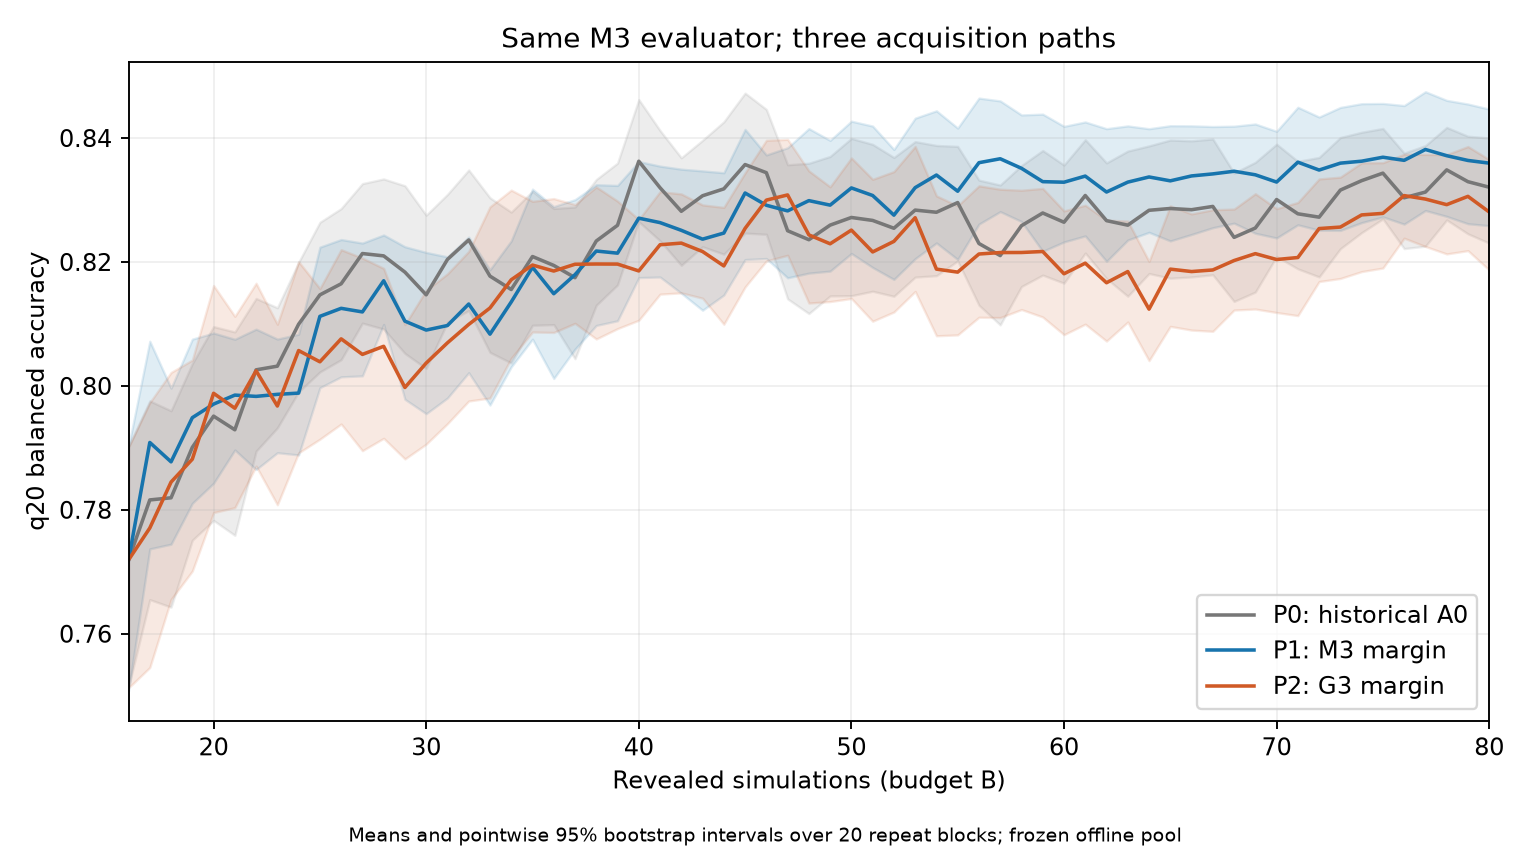

In [8]:
display(contrasts[contrasts.inference_role!='primary'])
display(Image(filename=str(OUT/'figures/01_q20_learning_curve.png')))

## 9. What changed in the paths?

Jaccard overlap compares sets of revealed rows: 1 means identical sets and 0 means no shared rows. Prefix overlap includes the shared initial 16; active-only overlap excludes them. Class counts describe sampling composition. They are post-hoc diagnostics, not causal explanations. Selector margins from G3 and M3 need not have the same calibration.

In [9]:
display(pd.read_csv(OUT/'path_overlap_summary.csv'))
mechanism=pd.read_csv(OUT/'mechanism_summary.csv')
display(mechanism[mechanism.budget.isin([16,24,40,80])])

,contrast,budget,prefix_jaccard,active_only_jaccard,different_sequence
0,P2-P0,24,0.559858,0.086392,1.0
1,P2-P0,40,0.536657,0.334399,1.0
2,P2-P0,80,0.713750,0.656981,1.0
3,P2-P1,24,0.550224,0.071443,1.0
4,P2-P1,40,0.520285,0.314178,1.0
5,P2-P1,80,0.620217,0.548892,1.0


,model,budget,keyhole_count,keyhole_fraction
0,P0,16,5.17,0.323125
8,P0,24,9.44,0.393333
24,P0,40,17.37,0.434250
64,P0,80,29.06,0.363250
65,P1,16,5.17,0.323125
73,P1,24,9.00,0.375000
89,P1,40,16.43,0.410750
129,P1,80,32.08,0.401000
130,P2,16,5.17,0.323125
138,P2,24,8.74,0.364167


## 10. Thesis interpretation

The practical threshold was frozen at 0.01 AULC before P2 results. A supported gain must also have an interval above zero. This experiment tests acquisition paths with the same evaluator on the frozen offline pool. It cannot establish prospective savings, external validity, or physical causality.

In [10]:
display(Markdown((OUT/'SUPERVISOR_SUMMARY.md').read_text()))

# Phase 1.20 â€” discussion with Ioan

**Question:** Can standalone G3 select better queries while M3 remains the evaluator?

**Controlled comparison:** 405 frozen simulations; 100 identical grouped outer splits; shared 16-point starts. P0 = historical isotropic-GPC path; P1 = M3-margin path; P2 = new sequential ARD G3-margin path. All paths use the exact M3 evaluator.

**Primary, q20 balanced-accuracy AULC B16â€“B40:** P2âˆ’P1 = -0.002560 (95% repeat-block interval [-0.010570, +0.005446]); 9/20 repeat blocks positive.

**Full B16â€“B80:** P2âˆ’P1 = -0.007014 (95% repeat-block interval [-0.011681, -0.002494]); 7/20 repeat blocks positive.

**Historical control:** early P2âˆ’P0 = -0.005724 (95% repeat-block interval [-0.012324, +0.000581]); 7/20 repeat blocks positive.

**Decision:** G3_SELECTOR_SMALL_OR_UNRESOLVED. Retain M3-margin; this result does not justify replacing it.

The practical threshold (0.01 AULC) was frozen before P2 results. Earlier reported Phase 1.14 numbers were accuracy, not balanced accuracy. This is evidence about offline acquisition paths, not prospective simulation savings or G3 predictive superiority.
